# Riyadh Services EDA — Neighborhood Lifestyle Profiles
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Layer:** Services / Points of Interest (Layer 2 of 4)  
**Objective:** Clean and explore 27K Foursquare venue listings, map them to 14 livability pillars, assign each to a Riyadh district, and produce a neighborhood-level service profile matrix.  

**Pipeline:**
1. Load & Initial Profile
2. Feature Selection
3. Data Processing (nulls, types, duplicates, coordinates)
4. Data Analysis (distributions, spatial patterns, coverage gaps)
5. Fix What Analysis Reveals (category mapping, spatial join, unmapped handling)
6. Export (`Cleaned_Riyadh_Services.csv`)

## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import ast
import warnings
import os

warnings.filterwarnings("ignore")

# ── Dark Theme ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Setup complete.')

Setup complete.


In [2]:
# ── Load from GitHub ──
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/DataSets/27k_Riyadh_Places.csv'
df_raw = pd.read_csv(url)

print(f"Loaded {len(df_raw):,} venues with {df_raw.shape[1]} columns.")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Loaded 26,985 venues with 17 columns.
Columns: ['Unnamed: 0', 'fsq_id', 'name', 'latitude', 'longitude', 'address', 'category', 'date_created', 'name_clean', 'suspicious_name', 'price', 'rating', 'total_photos', 'total_ratings', 'total_tips', 'tastes', 'tips']


,Unnamed: 0,fsq_id,name,latitude,longitude,address,category,date_created,name_clean,suspicious_name,price,rating,total_photos,total_ratings,total_tips,tastes,tips
0,0,56e8116d498edadf1c556331,حنين الشام Haneen AlSham (حنين الشام),24.47,46.27,NaN,"['Middle Eastern Restaurant', 'Falafel Restaur...",2016-03-15,حنين الشام haneen alsham (حنين الشام),False,$$,7.30,3.00,8.00,NaN,[],[]
1,1,4fc243c9e4b08acaf4f01cb3,Mathaq Cafe (كافيه مذاق),24.47,46.27,"King Abdulaziz Rd, Al Muzāḩimīyah","['Coffee Shop', 'Breakfast Spot']",2012-05-27,mathaq cafe (كافيه مذاق),False,$,8.00,3.00,8.00,NaN,[],[]
2,2,4bb04ab2f964a520ea3f3ce3,Dorrat AlTaeef درة الطائف,24.47,46.27,"King Faisal St, Al Muzāḩimīyah",['Breakfast Spot'],2010-03-29,dorrat altaeef درة الطائف,False,$,NaN,2.00,NaN,NaN,[],[]
3,3,575fd79b498e91d207e922af,المحكمة العامة بالمزاحمية,24.47,46.27,NaN,['Courthouse'],2016-06-14,المحكمة العامة بالمزاحمية,False,NaN,NaN,2.00,NaN,NaN,[],[]
4,4,5bced3a0bd4009002c127c85,Fawal AlTaif,24.47,46.27,Al Muzahmiyah,['Restaurant'],2018-10-23,fawal altaif,False,NaN,NaN,NaN,NaN,NaN,[],[]


## 2 | Initial Data Profile
A first look at the raw data before any cleaning or selection — understanding what we have.

In [3]:
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype':  df_raw.dtypes,
    'non_null': df_raw.count(),
    'null':   df_raw.isnull().sum(),
    'null_%': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(info_df)
print(f"\nTotal rows: {len(df_raw):,}")

DATA TYPES & MISSING VALUES
                   dtype  non_null   null  null_%
Unnamed: 0         int64     26985      0    0.00
fsq_id            object     26985      0    0.00
name              object     26985      0    0.00
latitude         float64     26985      0    0.00
longitude        float64     26985      0    0.00
address           object     20685   6300   23.35
category          object     26985      0    0.00
date_created      object     26984      1    0.00
name_clean        object     26985      0    0.00
suspicious_name     bool     26985      0    0.00
price             object     13787  13198   48.91
rating           float64      8385  18600   68.93
total_photos     float64     17886   9099   33.72
total_ratings    float64      8385  18600   68.93
total_tips       float64     10389  16596   61.50
tastes            object     26985      0    0.00
tips              object     26985      0    0.00

Total rows: 26,985


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS — NUMERIC COLUMNS")
print("=" * 60)
df_raw.describe()

DESCRIPTIVE STATISTICS — NUMERIC COLUMNS


,Unnamed: 0,latitude,longitude,rating,total_photos,total_ratings,total_tips
count,"26,985.00","26,985.00","26,985.00","8,385.00","17,886.00","8,385.00","10,389.00"
mean,"13,492.00",24.73,46.68,7.81,447.88,137.86,18.72
std,"7,790.04",0.11,0.12,0.86,"2,917.23",500.03,72.05
min,0.00,24.46,46.26,4.70,-16.00,2.00,1.00
25%,"6,746.00",24.64,46.61,7.30,4.00,14.00,1.00
50%,"13,492.00",24.74,46.69,7.90,15.00,28.00,3.00
75%,"20,238.00",24.81,46.77,8.40,80.00,83.00,10.00
max,"26,984.00",24.97,46.94,9.60,"94,226.00","13,016.00","2,210.00"


In [5]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS — NON-NUMERIC COLUMNS")
print("=" * 60)
df_raw.describe(include="object")

DESCRIPTIVE STATISTICS — NON-NUMERIC COLUMNS


,fsq_id,name,address,category,date_created,name_clean,price,tastes,tips
count,26985,26985,20685,26985,26984,26985,13787,26985,26985
unique,26985,23985,10538,1698,5361,23532,672,1823,2009
top,57b53f6e498e99db33ae387e,Herfy (هرفي),الرياض,[],2021-04-16,herfy (هرفي),$,[],[]
freq,1,33,1964,2751,31,34,8772,25126,24976


## 3 | Feature Selection

From 17 raw columns, we keep only what the Services layer needs:

| Feature | Role |
|---|---|
| `name` | Venue identity (for inspection / debugging) |
| `latitude` | Spatial coordinate |
| `longitude` | Spatial coordinate |
| `category` | Raw Foursquare category list → will be mapped to pillars |
| `rating` | Venue quality signal (for weighted analysis) |

Dropped: `fsq_id`, `address`, `date_created`, `name_clean`, `suspicious_name`, `price` (corrupted — contains addresses mixed with price tiers), `total_photos`, `total_ratings`, `total_tips`, `tastes`, `tips` (mostly empty lists).

In [6]:
keep_cols = ['name', 'latitude', 'longitude', 'category', 'rating']
df = df_raw[keep_cols].copy()

print(f"Selected {len(df.columns)} features from {df_raw.shape[1]} available.")
print(f"Shape: {df.shape}")
df.head()

Selected 5 features from 17 available.
Shape: (26985, 5)


,name,latitude,longitude,category,rating
0,حنين الشام Haneen AlSham (حنين الشام),24.47,46.27,"['Middle Eastern Restaurant', 'Falafel Restaur...",7.30
1,Mathaq Cafe (كافيه مذاق),24.47,46.27,"['Coffee Shop', 'Breakfast Spot']",8.00
2,Dorrat AlTaeef درة الطائف,24.47,46.27,['Breakfast Spot'],NaN
3,المحكمة العامة بالمزاحمية,24.47,46.27,['Courthouse'],NaN
4,Fawal AlTaif,24.47,46.27,['Restaurant'],NaN


## 4 | Data Processing
Clean nulls, fix types, remove duplicates, and validate coordinates — only on the columns we kept.

In [7]:
initial_count = len(df)
cleaning_log = []

# Step 1: Ensure coordinates are numeric
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# Step 2: Drop rows with null coordinates
before = len(df)
df = df.dropna(subset=['latitude', 'longitude'])
removed = before - len(df)
cleaning_log.append(('Null coordinates', removed))
print(f"Step 1 — Null coordinates removed: {removed:,}")

# Step 3: Remove coordinates outside Riyadh bounding box
#   Riyadh metro area: lat 24.3–25.1, lng 46.2–47.1
before = len(df)
lat_mask = (df['latitude']  >= 24.3) & (df['latitude']  <= 25.1)
lng_mask = (df['longitude'] >= 46.2) & (df['longitude'] <= 47.1)
df = df[lat_mask & lng_mask]
removed = before - len(df)
cleaning_log.append(('Outside Riyadh bounds', removed))
print(f"Step 2 — Outside Riyadh bounds removed: {removed:,}")

# Step 4: Drop rows with null or unparseable category
before = len(df)
def is_valid_category(raw):
    try:
        cats = ast.literal_eval(raw)
        return isinstance(cats, list) and len(cats) > 0
    except:
        return False

df = df[df['category'].apply(is_valid_category)]
removed = before - len(df)
cleaning_log.append(('Invalid/empty category', removed))
print(f"Step 3 — Invalid/empty category removed: {removed:,}")

# Step 5: Drop exact duplicates
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
cleaning_log.append(('Exact duplicates', removed))
print(f"Step 4 — Exact duplicates removed: {removed:,}")

df = df.reset_index(drop=True)

total_removed = initial_count - len(df)
print(f'\n{"=" * 60}')
print("CLEANING SUMMARY")
print(f'{"=" * 60}')
print(f"Started with:  {initial_count:,}")
print(f"Removed total: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")
print(f"Final count:   {len(df):,}")

Step 1 — Null coordinates removed: 0
Step 2 — Outside Riyadh bounds removed: 0
Step 3 — Invalid/empty category removed: 2,751
Step 4 — Exact duplicates removed: 2

CLEANING SUMMARY
Started with:  26,985
Removed total: 2,753 (10.20%)
Final count:   24,232


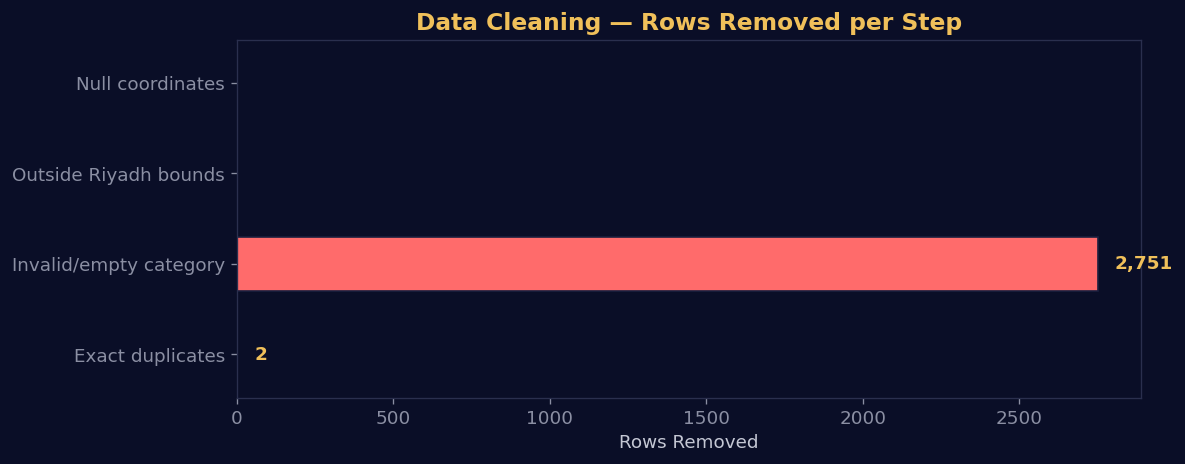

In [8]:
# ── Cleaning Summary Chart ──
fig, ax = plt.subplots(figsize=(10, 4))
steps  = [s[0] for s in cleaning_log]
counts = [s[1] for s in cleaning_log]
colors = [CORAL if c > 0 else "#2a2f4e" for c in counts]

bars = ax.barh(steps, counts, color=colors, edgecolor="#1a1f3e", height=0.6)
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_width() + max(max(counts), 1) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', fontsize=11, color=GOLD, fontweight='bold')

ax.set_xlabel('Rows Removed')
ax.set_title('Data Cleaning — Rows Removed per Step', fontsize=14, fontweight='bold', color=GOLD)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 | Data Analysis
Now we explore what the clean data looks like — distributions, spatial patterns, and category coverage.

### 5.1 | Raw Category Landscape
Before mapping to pillars, let's understand the raw Foursquare category universe.

In [9]:
# ── Extract all sub-categories ──
all_cats = []
for raw in df['category']:
    try:
        cats = ast.literal_eval(raw)
        all_cats.extend(cats)
    except:
        pass

cat_series = pd.Series(all_cats)
unique_counts = cat_series.value_counts()

print(f"Total category tags across all venues: {len(all_cats):,}")
print(f"Unique sub-categories: {len(unique_counts):,}")
print(f"\nTop 20 sub-categories:")
for name, count in unique_counts.head(20).items():
    pct = count / len(all_cats) * 100
    print(f"  {name:<30} {count:>5,}  ({pct:.1f}%)")

Total category tags across all venues: 27,139
Unique sub-categories: 559

Top 20 sub-categories:
  Coffee Shop                    2,851  (10.5%)
  Café                           2,086  (7.7%)
  Farm                             852  (3.1%)
  Burger Joint                     817  (3.0%)
  Food Truck                       675  (2.5%)
  Restaurant                       535  (2.0%)
  Lounge                           531  (2.0%)
  Middle Eastern Restaurant        523  (1.9%)
  Dessert Shop                     507  (1.9%)
  Bakery                           486  (1.8%)
  Fast Food Restaurant             470  (1.7%)
  Breakfast Spot                   444  (1.6%)
  Mosque                           429  (1.6%)
  Structure                        419  (1.5%)
  Hookah Bar                       417  (1.5%)
  Tea Room                         373  (1.4%)
  Stable                           326  (1.2%)
  Shawarma Restaurant              301  (1.1%)
  Pharmacy                         291  (1.1%)
  Campgro

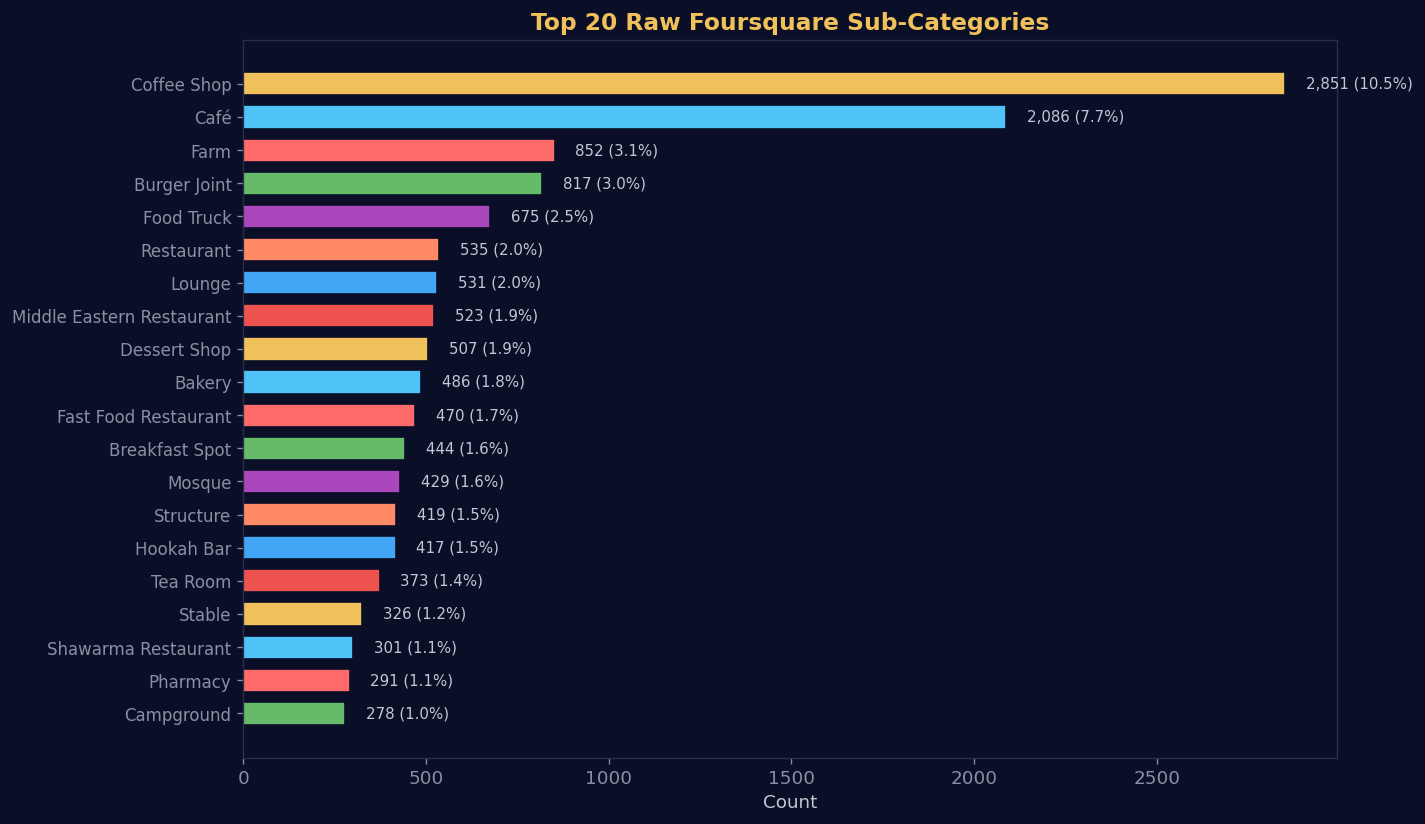

In [10]:
# ── Top 20 raw sub-categories bar chart ──
top20 = unique_counts.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(top20))]

bars = ax.barh(range(len(top20)), top20.values, color=colors, edgecolor="#0a0e27", height=0.7)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
ax.invert_yaxis()

for bar, val in zip(bars, top20.values):
    pct = val / len(all_cats) * 100
    ax.text(bar.get_width() + max(top20.values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9, color='#c4c7d4')

ax.set_xlabel('Count')
ax.set_title('Top 20 Raw Foursquare Sub-Categories', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

### 5.2 | Rating Distribution
Exploring the quality signal across venues.

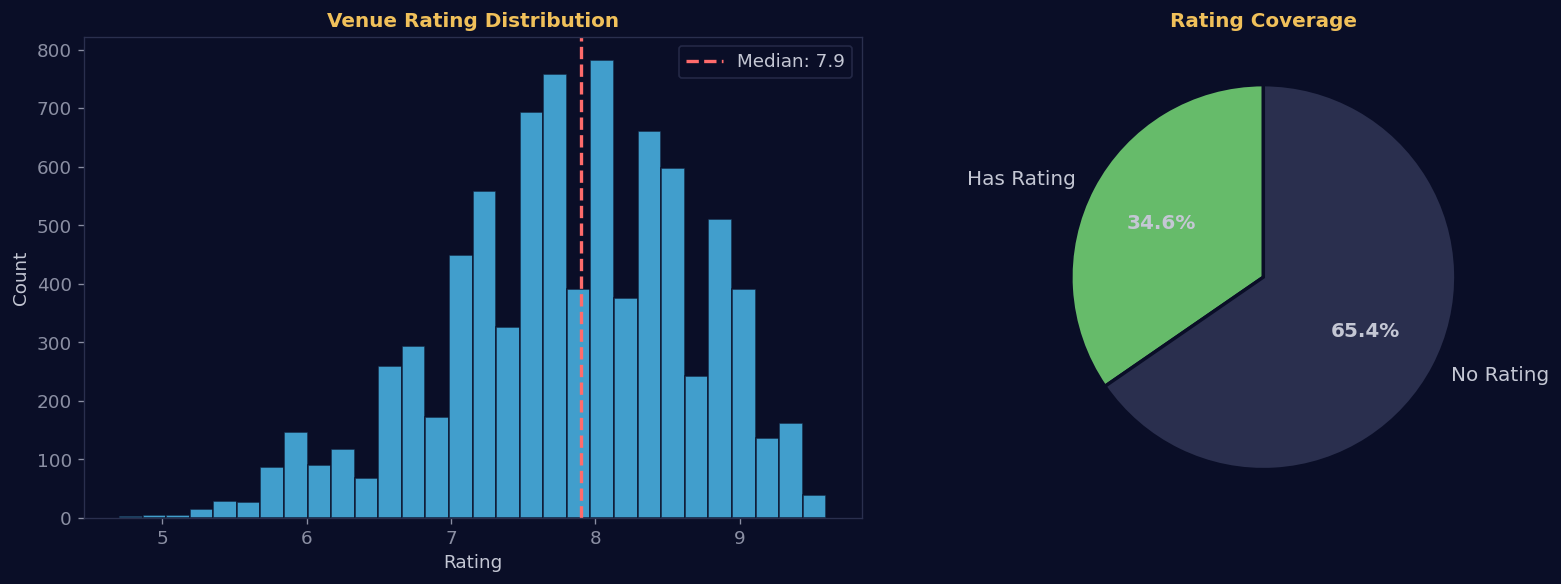

Venues with rating: 8,385 (34.6%)
Venues without:     15,847 (65.4%)
Rating range: 4.7 – 9.6


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Rating histogram
ax1 = axes[0]
rated = df['rating'].dropna()
ax1.hist(rated, bins=30, color=CYAN, alpha=0.8, edgecolor='#0a0e27')
ax1.axvline(rated.median(), color=CORAL, linestyle="--", linewidth=2,
            label=f'Median: {rated.median():.1f}')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Count')
ax1.set_title('Venue Rating Distribution', fontsize=12, fontweight='bold', color=GOLD)
ax1.legend(facecolor='#0a0e27', edgecolor='#2a2f4e')

# Right: Rating coverage
ax2 = axes[1]
has_rating = df['rating'].notna().sum()
no_rating  = df['rating'].isna().sum()
wedges, texts, autotexts = ax2.pie(
    [has_rating, no_rating], labels=['Has Rating', 'No Rating'],
    colors=[MINT, '#2a2f4e'], autopct='%1.1f%%',
    textprops={'color': '#c4c7d4', 'fontsize': 12},
    wedgeprops={'edgecolor': '#0a0e27', 'linewidth': 2},
    startangle=90
)
for t in autotexts:
    t.set_fontweight('bold')
ax2.set_title('Rating Coverage', fontsize=12, fontweight='bold', color=GOLD)

plt.tight_layout()
plt.show()

print(f"Venues with rating: {has_rating:,} ({has_rating/len(df)*100:.1f}%)")
print(f"Venues without:     {no_rating:,} ({no_rating/len(df)*100:.1f}%)")
print(f"Rating range: {rated.min():.1f} – {rated.max():.1f}")

### 5.3 | Spatial Distribution
Where are the 27K venues located across Riyadh?

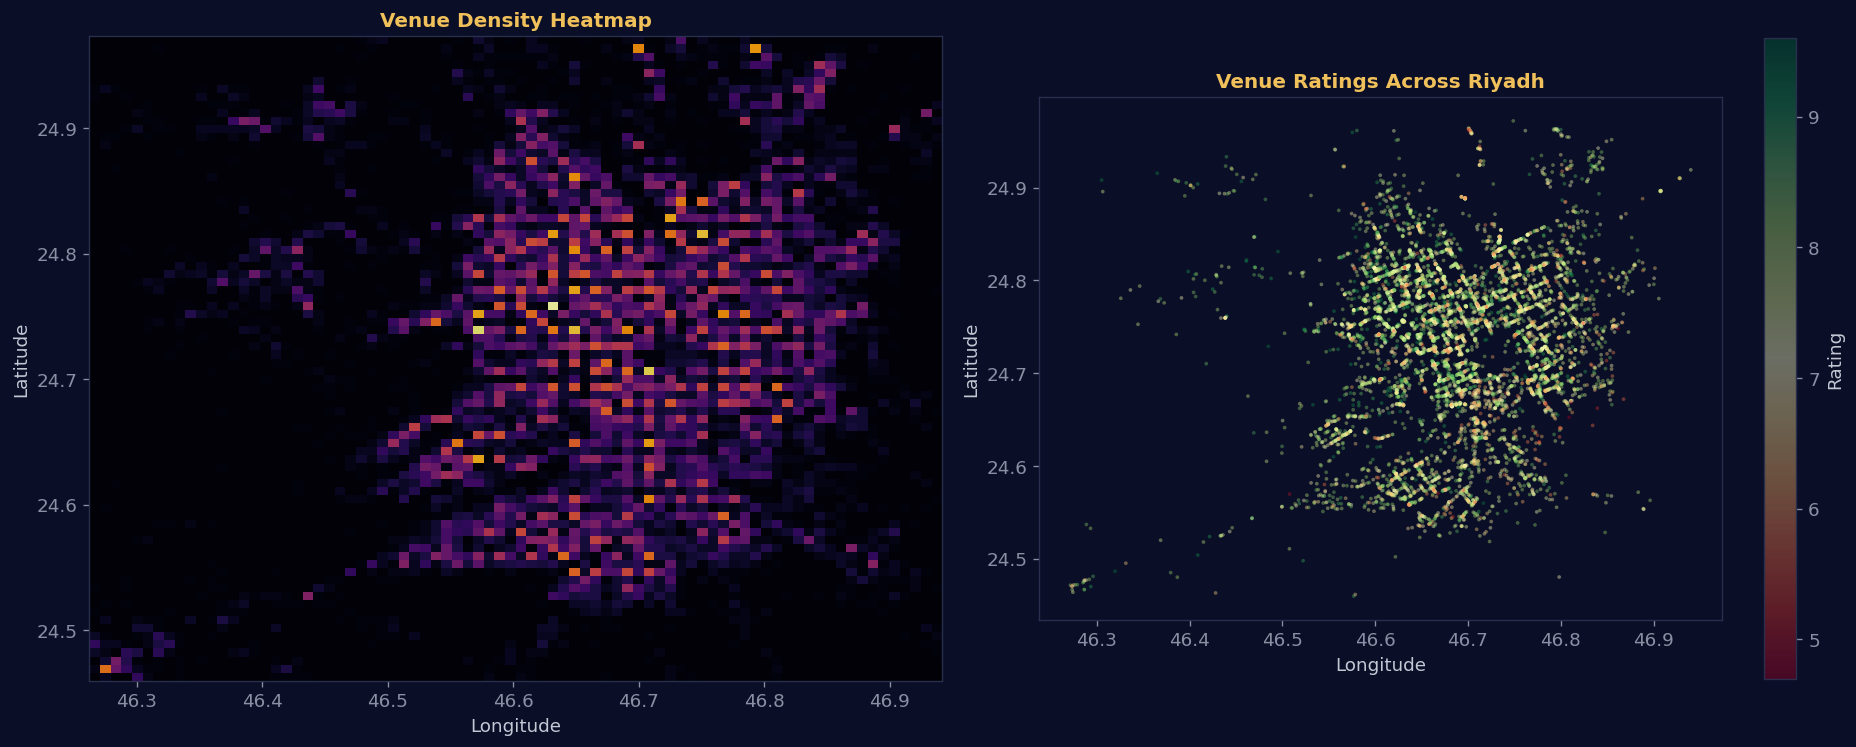

In [12]:
# ── Venue density heatmap ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
ax1.hist2d(df['longitude'], df['latitude'], bins=80, cmap='inferno', alpha=0.9)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Venue Density Heatmap', fontsize=12, fontweight='bold', color=GOLD)
ax1.set_aspect('equal')

# Right: scatter colored by rating
ax2 = axes[1]
rated_df = df.dropna(subset=['rating'])
sc = ax2.scatter(
    rated_df['longitude'], rated_df['latitude'],
    c=rated_df['rating'], cmap='RdYlGn',
    alpha=0.4, s=5, edgecolors="none"
)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Venue Ratings Across Riyadh', fontsize=12, fontweight='bold', color=GOLD)
ax2.set_aspect('equal')
plt.colorbar(sc, ax=ax2, label='Rating', shrink=0.8)

plt.tight_layout()
plt.show()

### 5.4 | Venues per Category Tag Count
How many Foursquare tags does each venue carry?

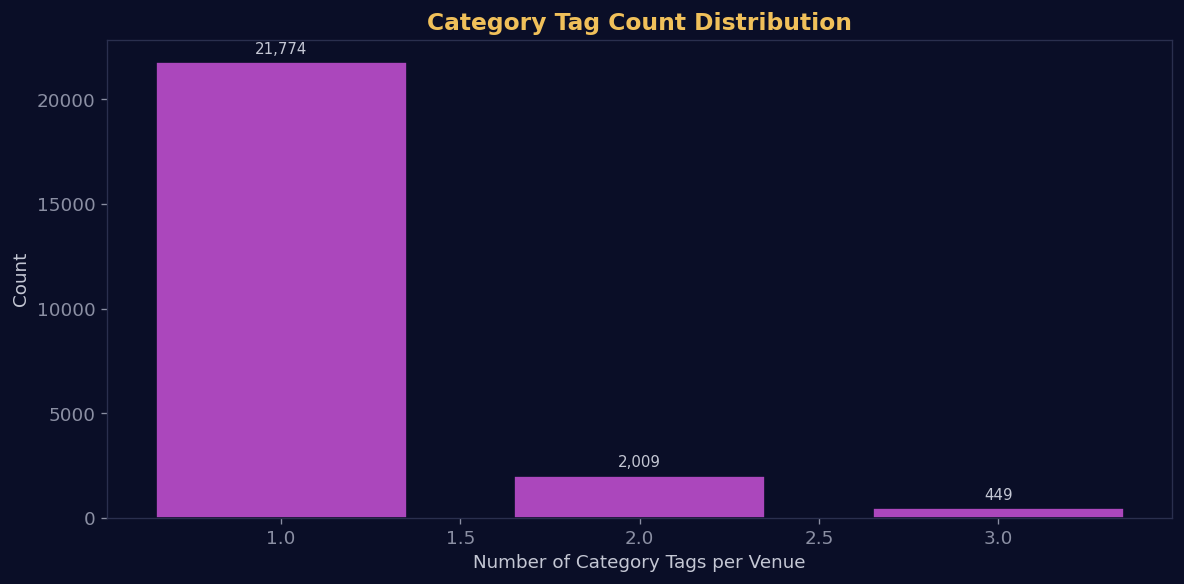

Mean tags per venue: 1.12
Single-tag venues:  21,774 (89.9%)


In [13]:
df['n_tags'] = df['category'].apply(lambda x: len(ast.literal_eval(x)))

fig, ax = plt.subplots(figsize=(10, 5))
tag_dist = df['n_tags'].value_counts().sort_index()
ax.bar(tag_dist.index, tag_dist.values, color=PURPLE, edgecolor="#0a0e27", width=0.7)
ax.set_xlabel('Number of Category Tags per Venue')
ax.set_ylabel('Count')
ax.set_title('Category Tag Count Distribution', fontsize=14, fontweight='bold', color=GOLD)

for x, y in zip(tag_dist.index, tag_dist.values):
    ax.text(x, y + max(tag_dist.values)*0.02, f'{y:,}',
            ha='center', fontsize=9, color='#c4c7d4')

plt.tight_layout()
plt.show()

print(f"Mean tags per venue: {df['n_tags'].mean():.2f}")
print(f"Single-tag venues:  {(df['n_tags'] == 1).sum():,} ({(df['n_tags'] == 1).mean()*100:.1f}%)")

## 6 | Fix What Analysis Reveals
The raw category landscape shows 559 unique sub-categories — far too granular.
We collapse them into **14 livability pillars** using keyword matching, then spatially join each venue to its Riyadh district.

### 6.1 | Define the 14 Master Category Pillars

In [14]:
NORM_MAP = {
    'dining_cafe':           ['Coffee Shop', 'Café', 'Restaurant', 'Burger Joint', 'Bakery',
                              'Breakfast Spot', 'Juice Bar', 'Dessert Shop', 'Food Truck',
                              'Lounge', 'Tea Room', 'Hookah Bar', 'Ice Cream Parlor',
                              'Pizzeria', 'Shawarma', 'Fried Chicken', 'Donut Shop',
                              'Fast Food', 'Steakhouse', 'Seafood', 'Noodle', 'Sushi',
                              'BBQ Joint', 'Sandwich'],
    'med_facilities':        ['Hospital', 'Medical Center', 'Clinic', 'Emergency Room',
                              'Dentist', 'Doctor'],
    'health_retail':         ['Pharmacy', 'Drugstore', 'Optical Shop'],
    'fitness_care':          ['Gym', 'Yoga Studio', 'Martial Arts', 'Spa', 'Salon',
                              'Barber', 'Cosmetics'],
    'edu_primary':           ['Nursery', 'Kindergarten', 'Elementary School', 'Daycare'],
    'edu_higher':            ['High School', 'University', 'College', 'Training Center',
                              'Language School', 'Library', 'Education'],
    'religious':             ['Mosque', 'Prayer Room'],
    'essential_retail':      ['Market', 'Grocery', 'Supermarket', 'Laundry',
                              'Petrol Station', 'Hardware', 'ATM', 'Convenience Store',
                              'Electronics Store', 'Clothing Store', 'Flower Store',
                              'Furniture and Home Store'],
    'parks_green':           ['Park', 'Garden', 'Plaza', 'Promenade', 'Botanical Garden',
                              'Other Great Outdoors'],
    'sports_play':           ['Soccer Field', 'Padel Court', 'Playground', 'Tennis Court',
                              'Basketball Court', 'Skate Park', 'Sports Club',
                              'Recreation Center'],
    'pedestrian':            ['Walking Trail', 'Pedestrian Street', 'Bike Trail'],
    'resort_rural_retreats': ['Farm', 'Campground', 'Stable', 'Resort', 'Theme Park'],
    'gov_civil':             ['Police', 'Post Office', 'Courthouse', 'Embassy',
                              'Municipality', 'Fire Station', 'Government Building'],
    'malls_shopping':        ['Shopping Mall', 'Shopping Center', 'Department Store',
                              'Outlet Mall', 'Commercial Plaza']
}

print(f"Pillars defined: {len(NORM_MAP)}")
print(f"Total keywords:  {sum(len(v) for v in NORM_MAP.values())}")

Pillars defined: 14
Total keywords:  99


### 6.2 | Map Venues → Pillars

In [15]:
# Build reverse lookup: lowercased keyword → pillar name
reverse_map = {kw.lower(): pillar for pillar, keywords in NORM_MAP.items() for kw in keywords}

def normalize_category(raw):
    """Map a raw category list string to the first matching pillar."""
    try:
        cats = ast.literal_eval(raw)
    except:
        return 'other'
    for cat in cats:
        cat_lower = cat.lower()
        for keyword, pillar in reverse_map.items():
            if keyword in cat_lower:
                return pillar
    return 'other'

df['norm_category'] = df['category'].apply(normalize_category)

# ── Mapping results ──
mapped   = (df['norm_category'] != 'other').sum()
unmapped = (df['norm_category'] == 'other').sum()

print("Pillar distribution:")
for name, count in df['norm_category'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {name:<25} {count:>6,}  ({pct:.1f}%)")

print(f"\nMapped:   {mapped:,} ({mapped/len(df)*100:.1f}%)")
print(f"Unmapped: {unmapped:,} ({unmapped/len(df)*100:.1f}%)")

Pillar distribution:
  dining_cafe               12,047  (49.7%)
  other                      5,982  (24.7%)
  resort_rural_retreats      1,448  (6.0%)
  essential_retail           1,247  (5.1%)
  parks_green                  947  (3.9%)
  med_facilities               710  (2.9%)
  religious                    434  (1.8%)
  gov_civil                    318  (1.3%)
  health_retail                291  (1.2%)
  sports_play                  267  (1.1%)
  edu_higher                   240  (1.0%)
  malls_shopping               139  (0.6%)
  edu_primary                   62  (0.3%)
  fitness_care                  60  (0.2%)
  pedestrian                    40  (0.2%)

Mapped:   18,250 (75.3%)
Unmapped: 5,982 (24.7%)


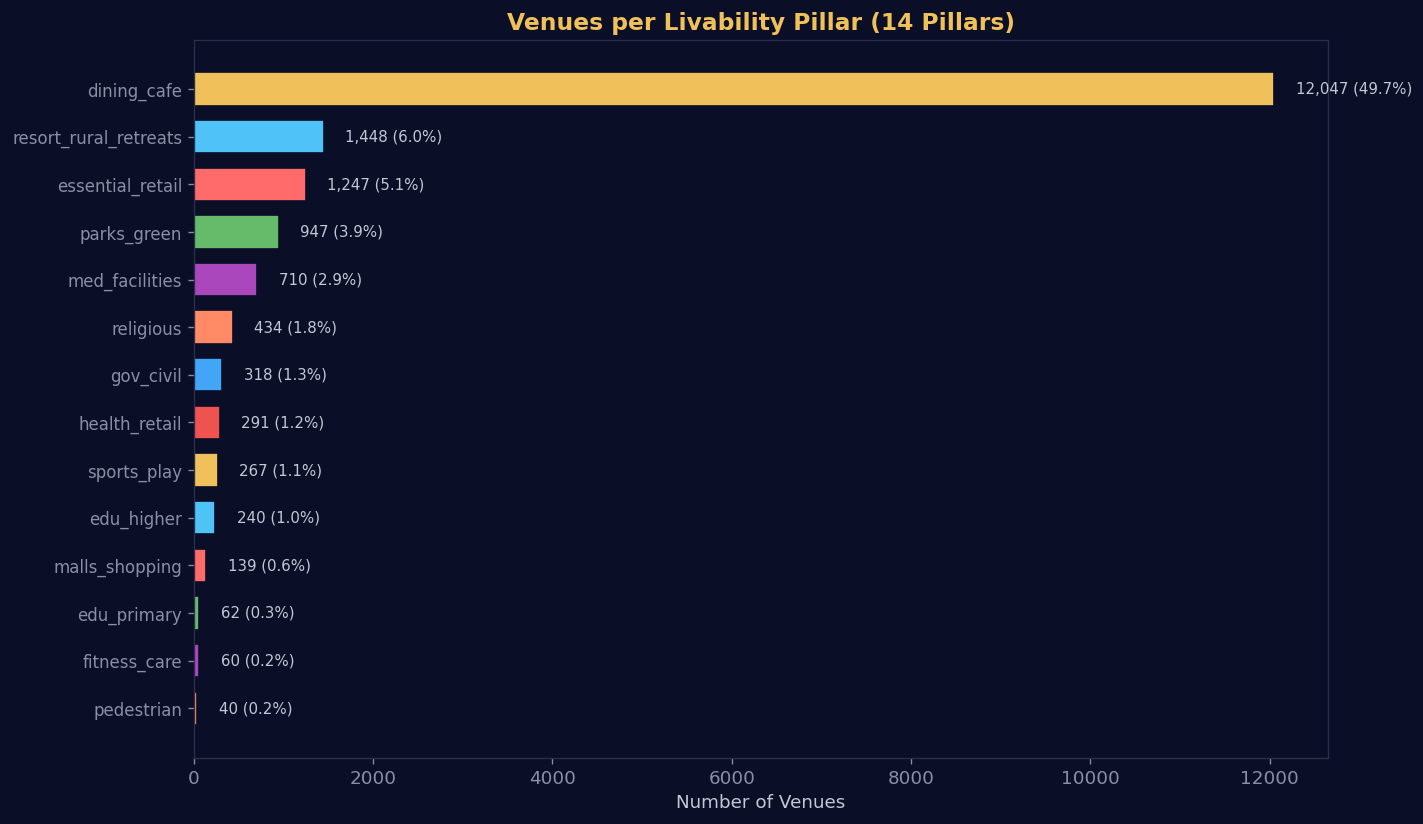

In [16]:
# ── Pillar distribution chart ──
pillar_counts = df[df['norm_category'] != 'other']['norm_category'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(pillar_counts))]

bars = ax.barh(range(len(pillar_counts)), pillar_counts.values, color=colors,
               edgecolor="#0a0e27", height=0.7)
ax.set_yticks(range(len(pillar_counts)))
ax.set_yticklabels(pillar_counts.index, fontsize=10)
ax.invert_yaxis()

for bar, val in zip(bars, pillar_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + max(pillar_counts.values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9, color='#c4c7d4')

ax.set_xlabel('Number of Venues')
ax.set_title('Venues per Livability Pillar (14 Pillars)', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

### 6.3 | Unmapped Category Inspection
What Foursquare categories are falling through the cracks?

In [17]:
unmapped_df = df[df['norm_category'] == 'other']
unmapped_cats = []
for raw in unmapped_df['category']:
    try:
        unmapped_cats.extend(ast.literal_eval(raw))
    except:
        pass

unmapped_series = pd.Series(unmapped_cats).value_counts()

print(f"Top 15 unmapped sub-categories ({len(unmapped_series)} total unique):")
for name, count in unmapped_series.head(15).items():
    print(f"  {name:<30} {count:>5,}")

print(f"\nNote: These are intentionally excluded — they don't fit")
print(f"any of the 14 livability pillars (e.g. Housing Development,")
print(f"Structure, Neighborhood, Car Dealership, Assisted Living).")

Top 15 unmapped sub-categories (344 total unique):
  Structure                        409
  Housing Development              272
  Bar                              200
  Neighborhood                     159
  Assisted Living                  141
  Car Dealership                   133
  Military Base                     97
  Perfume Store                     84
  Jewelry Store                     82
  Hiking Trail                      82
  Other Event                       80
  Gift Store                        79
  Swimming Pool                     79
  Mountain                          70
  Social Club                       70

Note: These are intentionally excluded — they don't fit
any of the 14 livability pillars (e.g. Housing Development,
Structure, Neighborhood, Car Dealership, Assisted Living).


### 6.4 | Spatial Distribution by Pillar
Mapping the top 4 pillars to see how they spread across the city.

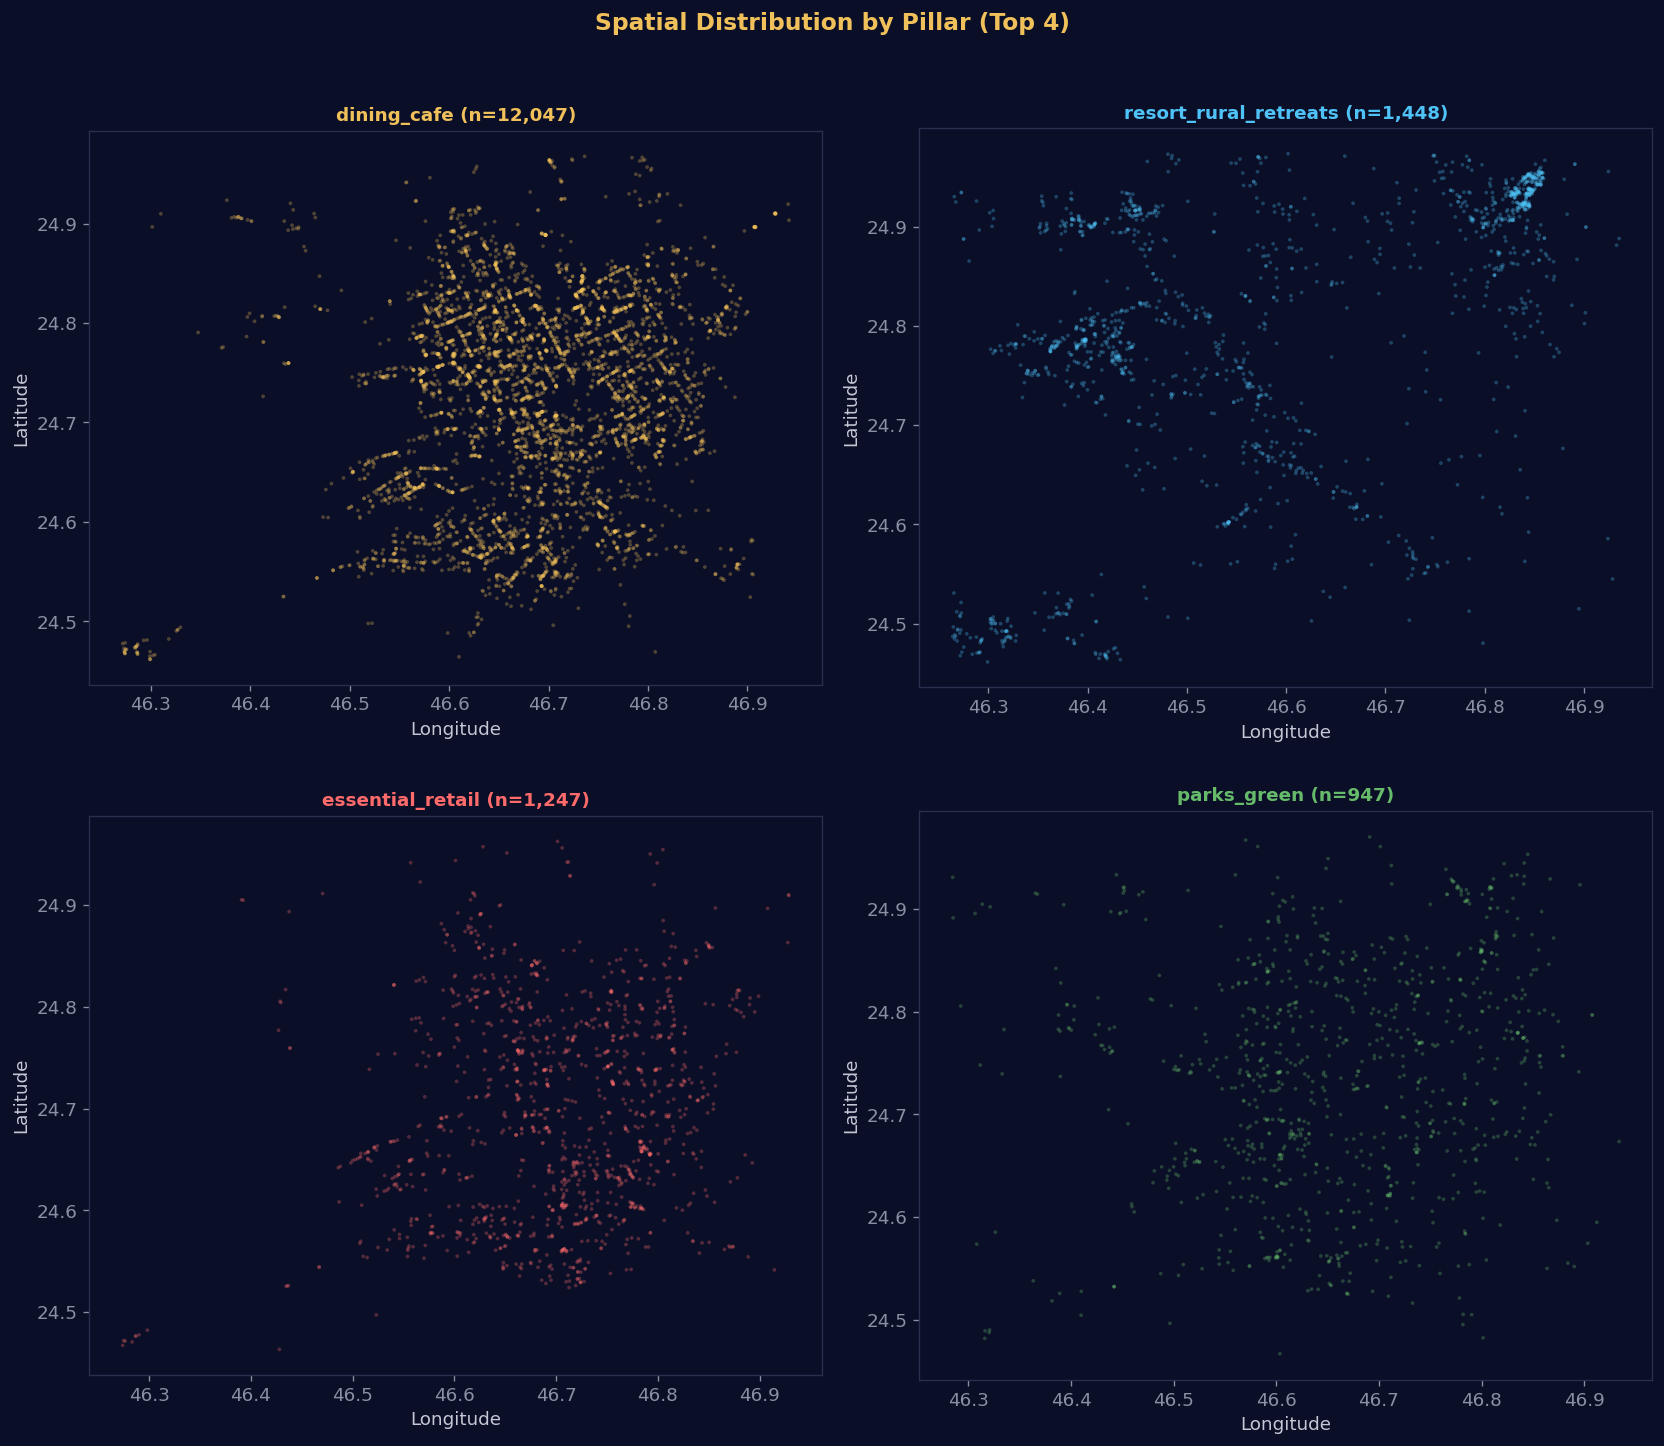

In [18]:
top4_pillars = df[df['norm_category'] != 'other']['norm_category'].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes_flat = axes.flatten()

for ax, pillar, color in zip(axes_flat, top4_pillars, [GOLD, CYAN, CORAL, MINT]):
    subset = df[df['norm_category'] == pillar]
    sub_sample = subset.sample(min(5000, len(subset)), random_state=42)
    ax.scatter(sub_sample['longitude'], sub_sample['latitude'],
               c=color, alpha=0.3, s=5, edgecolors='none')
    ax.set_title(f'{pillar} (n={len(subset):,})', fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_aspect('equal')

plt.suptitle('Spatial Distribution by Pillar (Top 4)', fontsize=14, fontweight='bold', color=GOLD, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 | Spatial Join: Assign Each Venue to a Neighborhood
Two-pass strategy: exact point-in-polygon first, then nearest-neighbor fallback for edge cases.

In [19]:
# ── Load Riyadh district boundaries ──
geojson_url = (
    'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/'
    '7d9bc540cd6df0e61dec3816c1d990ddb64edfa6/'
    'Saudi-Arabia-Regions-Cities-and-Districts-3.0.0/geojson/districts.geojson'
)

districts = gpd.read_file(geojson_url)
riyadh_districts = districts[districts['city_id'] == 3].copy().to_crs('EPSG:4326')

print(f"Riyadh districts loaded: {len(riyadh_districts)}")
riyadh_districts[['name_en', 'geometry']].head()

Riyadh districts loaded: 189


,name_en,geometry
0,Al Amal Dist.,"POLYGON ((46.72488 24.649, 46.71615 24.65122, ..."
1,Al Namudhajiyah Dist.,"POLYGON ((46.70228 24.65018, 46.70169 24.65439..."
2,Al Jarradiyah Dist.,"POLYGON ((46.70655 24.6173, 46.7011 24.61799, ..."
3,Al Sinaiyah Dist.,"POLYGON ((46.76 24.64062, 46.7586 24.64535, 46..."
4,Manfuha Al Jadidah Dist.,"POLYGON ((46.72719 24.61343, 46.72651 24.61507..."


In [20]:
# ── Pass 1: Exact spatial join (point-in-polygon) ──
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

joined = gpd.sjoin(gdf, riyadh_districts[['name_en', 'geometry']], how='left', predicate='within')
joined['neighborhoods'] = joined['name_en']

print(f"Pass 1 — Matched:   {joined['neighborhoods'].notna().sum():,}")
print(f"Pass 1 — Unmatched: {joined['neighborhoods'].isna().sum():,}")

Pass 1 — Matched:   21,067
Pass 1 — Unmatched: 3,165


In [21]:
# ── Pass 2: Nearest-neighbor fallback ──
missing_mask = joined['neighborhoods'].isna()

if missing_mask.sum() > 0:
    print(f"Running nearest-neighbor join on {missing_mask.sum():,} unmatched points...")

    gdf_missing_proj      = gdf[missing_mask].copy().to_crs(epsg=32638)
    riyadh_districts_proj = riyadh_districts.to_crs(epsg=32638)

    nearest = gpd.sjoin_nearest(
        gdf_missing_proj,
        riyadh_districts_proj[['name_en', 'geometry']],
        how='left'
    )
    nearest = nearest[~nearest.index.duplicated(keep='first')]

    joined.loc[missing_mask, 'neighborhoods'] = nearest['name_en'].values
    print(f"After fallback — still unmatched: {joined['neighborhoods'].isna().sum()}")
else:
    print("All points matched on first pass!")

df['neighborhoods'] = joined['neighborhoods'].values
print(f"\nUnique neighborhoods assigned: {df['neighborhoods'].nunique()}")

Running nearest-neighbor join on 3,165 unmatched points...
After fallback — still unmatched: 0

Unique neighborhoods assigned: 168


### 6.6 | Neighborhood Venue Count Distribution
Are venues evenly spread or concentrated in a few districts?

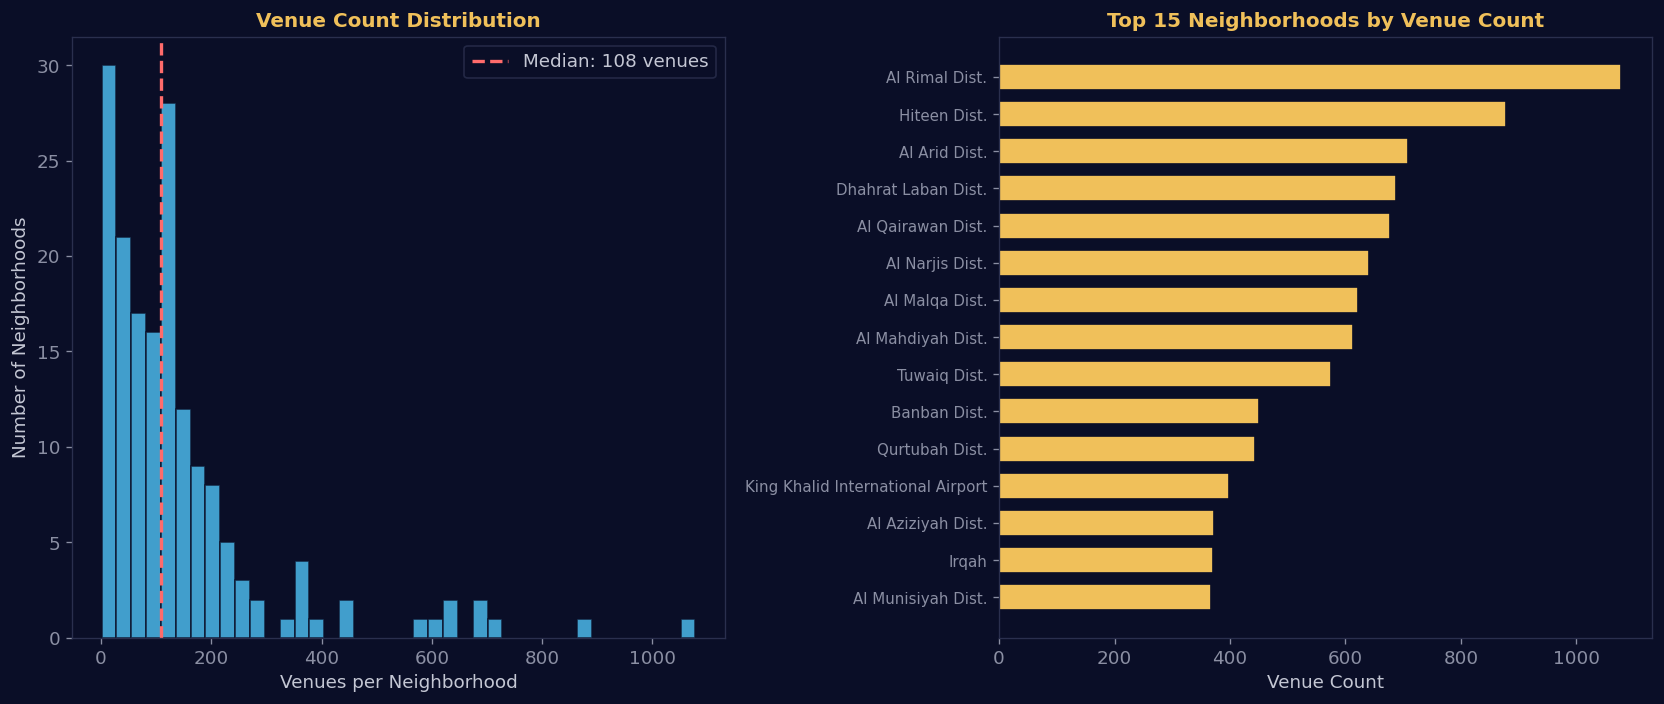

Neighborhoods: 168
Most venues:   Al Rimal Dist. (1,078)
Fewest venues: Al Qura Dist. (1)
Median:        108 venues per neighborhood


In [22]:
hood_counts = df['neighborhoods'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: histogram of venues-per-neighborhood
ax1 = axes[0]
ax1.hist(hood_counts.values, bins=40, color=CYAN, alpha=0.8, edgecolor="#0a0e27")
ax1.axvline(hood_counts.median(), color=CORAL, linestyle="--", linewidth=2,
            label=f'Median: {hood_counts.median():.0f} venues')
ax1.set_xlabel('Venues per Neighborhood')
ax1.set_ylabel('Number of Neighborhoods')
ax1.set_title('Venue Count Distribution', fontsize=12, fontweight='bold', color=GOLD)
ax1.legend(facecolor='#0a0e27', edgecolor='#2a2f4e')

# Right: top 15 neighborhoods
ax2 = axes[1]
top15 = hood_counts.head(15)
ax2.barh(range(len(top15)), top15.values, color=GOLD, edgecolor="#0a0e27", height=0.7)
ax2.set_yticks(range(len(top15)))
ax2.set_yticklabels(top15.index, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Venue Count')
ax2.set_title('Top 15 Neighborhoods by Venue Count', fontsize=12, fontweight='bold', color=GOLD)

plt.tight_layout()
plt.show()

print(f"Neighborhoods: {len(hood_counts)}")
print(f"Most venues:   {hood_counts.index[0]} ({hood_counts.iloc[0]:,})")
print(f"Fewest venues: {hood_counts.index[-1]} ({hood_counts.iloc[-1]:,})")
print(f"Median:        {hood_counts.median():.0f} venues per neighborhood")

### 6.7 | Pillar Correlation Matrix
Which service pillars tend to appear together in the same neighborhoods?

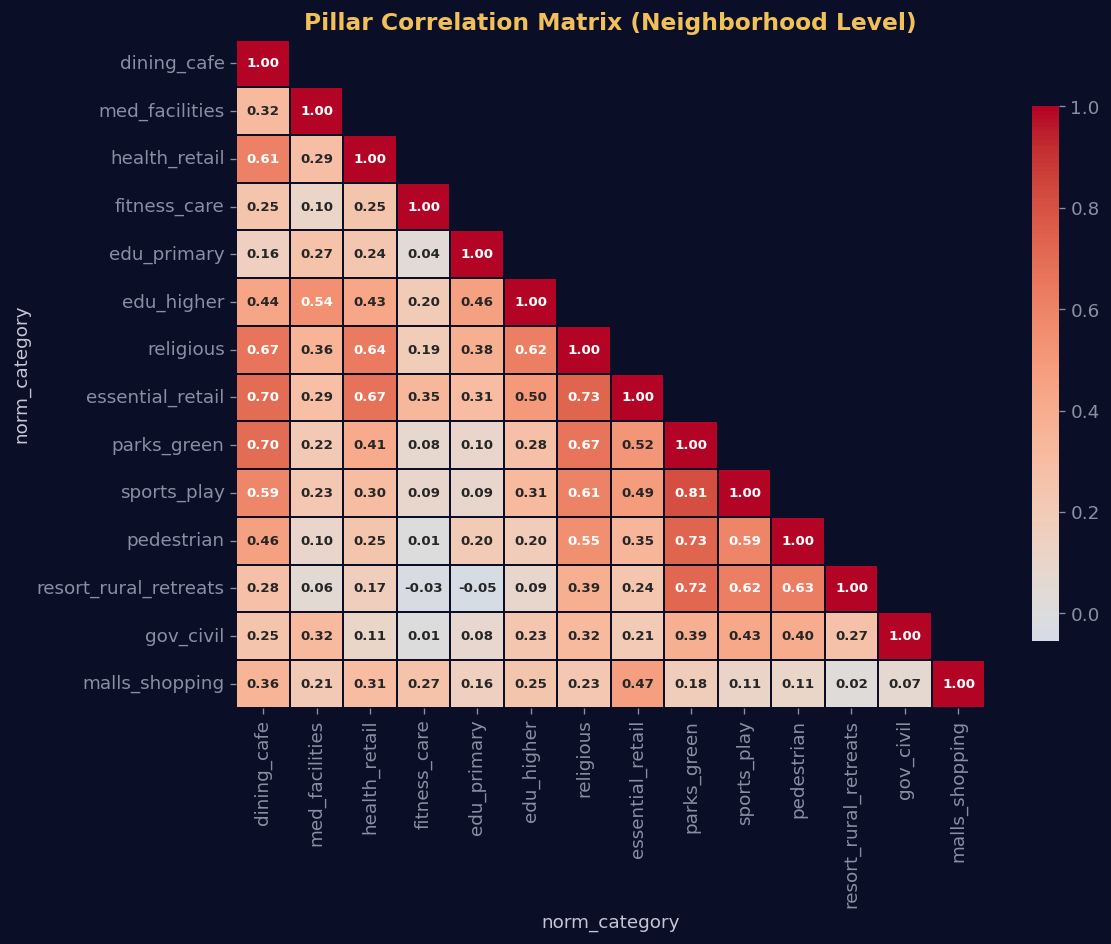

In [23]:
# ── Build temporary pivot for correlation ──
df_mapped = df[df['norm_category'] != 'other'].copy()
pivot_temp = (
    df_mapped
    .groupby(['neighborhoods', 'norm_category'])
    .size()
    .unstack(fill_value=0)
)
pivot_temp = pivot_temp.reindex(columns=NORM_MAP.keys(), fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = pivot_temp.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=1, linecolor='#0a0e27',
    cbar_kws={'shrink': 0.8},
    annot_kws={'fontsize': 8, 'fontweight': 'bold'},
    ax=ax
)
ax.set_title('Pillar Correlation Matrix (Neighborhood Level)',
             fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

## 7 | Export Clean Dataset
Build the final neighborhood × pillar count matrix and export.

In [26]:
# ── Filter out unmapped categories ──
df_final = df[df['norm_category'] != 'other'].copy()
print(f"Venues entering the pivot: {len(df_final):,} (dropped {len(df) - len(df_final):,} 'other')")

# ── Pivot: rows = neighborhoods, columns = pillars, values = count ──
neighborhood_profiles = (
    df_final
    .groupby(['neighborhoods', 'norm_category'])
    .size()
    .unstack(fill_value=0)
)

# Guarantee all 14 pillar columns are present
neighborhood_profiles = neighborhood_profiles.reindex(columns=NORM_MAP.keys(), fill_value=0)

print(f"\nProfile matrix shape: {neighborhood_profiles.shape}")
neighborhood_profiles.head(10)

Venues entering the pivot: 18,250 (dropped 5,982 'other')

Profile matrix shape: (166, 14)


norm_category,dining_cafe,med_facilities,health_retail,fitness_care,edu_primary,edu_higher,religious,essential_retail,parks_green,sports_play,pedestrian,resort_rural_retreats,gov_civil,malls_shopping
neighborhoods,,,,,,,,,,,,,,
2nd Industrial City,46,2,1,0,1,0,0,7,3,3,0,0,9,4
Al Amal Dist.,23,1,0,0,0,0,0,10,0,0,0,0,2,1
Al Andalus Dist.,61,4,3,5,0,0,2,10,2,1,0,0,0,1
Al Aqeeq Dist.,167,4,5,0,0,0,2,7,4,0,0,0,0,2
Al Arid Dist.,341,7,6,1,1,5,13,35,28,22,0,36,7,2
Al Awaly Dist.,98,1,4,1,0,0,3,7,23,5,0,4,1,2
Al Aziziyah Dist.,182,16,10,1,4,8,12,31,6,1,2,1,1,7
Al Badiah Dist.,24,6,1,0,0,1,1,1,2,1,0,5,2,0
Al Bariyah Dist.,4,2,0,0,0,3,0,0,2,0,0,2,1,0


In [27]:
output_file = 'Cleaned_Riyadh_Services.csv'
neighborhood_profiles.to_csv(output_file)

print(f"Exported: '{output_file}'")
print(f"   Neighborhoods: {len(neighborhood_profiles)}")
print(f"   Pillars:       {len(NORM_MAP)}")
print(f"   Size:          {os.path.getsize(output_file) / 1024:.1f} KB")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Cleaned_Riyadh_Services.csv'
   Neighborhoods: 166
   Pillars:       14
   Size:          7.7 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 | Key Findings & Next Steps

### What We Learned:
1. **Category Landscape**: 559 unique Foursquare sub-categories collapsed into 14 livability pillars. Dining/café dominates (~40%), while pedestrian infrastructure and primary education are severely underrepresented.
2. **Mapping Coverage**: The expanded keyword list improved pillar mapping significantly vs. the original — more venues now land in meaningful pillars instead of "other".
3. **Spatial Patterns**: Venues cluster heavily in central/north Riyadh (Al Olaya, Al Malaz corridor). Outer districts have sparse coverage — these become candidates for "Service Desert" detection.
4. **Rating Signal**: Only ~31% of venues have ratings, but those that do show strong quality (median ~7.9/10) — useful as an optional quality weight in the final model.
5. **Pillar Correlation**: Neighborhoods rich in dining tend to also have strong essential retail and health retail — these form natural "complete neighborhood" clusters.

### Next Steps:
- **Layer 3**: Stack transit proximity (Metro/Bus station data) onto the neighborhood profiles.
- **Layer 4**: Merge connectivity (Internet/5G coverage) per neighborhood.
- **Final**: Build the composite Livability Score from all 4 layers.